# Awinda — single-trial test

Minimal notebook for **one** awinda subject–trial pair. Same pipeline as `process_awinda.ipynb`:

- **IMU IK**: `mt_processed/{Subject}/ik/VQF/{speed}_{cond}.pkl` (cond is lowercase, e.g. `1p2mps_lg`)
- **OpenSim ID**: `processed/{Subject}/awinda/id/{COND}_{speed}_id.sto`
- **Sync**: first ankle moment negative peak (≤−0.8 N·m/kg, magnitude ≥0.8) on model prediction vs OpenSim ID

Change `SUBJECT` and `CONDITION` in the config cell, then re-run from there.


In [ ]:
import json
import pickle
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import ipywidgets as widgets
from IPython.display import display
from scipy.signal import butter, sosfilt, sosfiltfilt, find_peaks

warnings.filterwarnings('ignore', message='.*NumPy.*')

PROJECT_ROOT = Path('/home/metamobility3/Jinwoo/os_kinetics').resolve()
PROCESSED_ROOT = Path('/media/metamobility3/Samsung_T52/Results/processed')
IMU_IK_ROOT = Path('/home/metamobility3/Jinwoo/mt_processed')
IMU_IK_METHOD = 'VQF'
CHECKPOINT = PROJECT_ROOT / 'runs/0512_ik_id_all_zero_in_zero_out/best_model.pt'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# --- Change these to inspect another trial ---
SUBJECT = 'AB04_Changseob'
CONDITION = 'LG_1p2mps'  # e.g. LG_0p8mps, RA_0p8mps, RD_0p8mps, LG_1p2mps, LG_1p6mps

SUBJECT_MASS_KG = {
    'AB01_Jinwoo': 88.0, 'AB02_Oscar': 71.1, 'AB03_Ilseung': 84.4,
    'AB04_Changseob': 74.0, 'AB05_Maria': 55.0, 'AB06_Jimin': 82.6,
    'AB07_Amy': 51.3, 'AB08_Seokhyun': 71.9,
}

CHANNELS = [
    'hip_flexion_r', 'knee_angle_r', 'ankle_angle_r',
    'hip_flexion_l', 'knee_angle_l', 'ankle_angle_l',
]
ID_COLS = [f'{c}_moment' for c in CHANNELS]
DEFAULT_FS_HZ = 100.0
ALIGN_MAX_LAG_SEC = 30.0
ANKLE_MOMENT_NEG_PEAK_THRESHOLD_NMPKG = 0.8
PREVIEW_FRAMES = 500  # first 5 s at 100 Hz

sys.path.insert(0, str(PROJECT_ROOT))
from dataset import IK_DOF_NAMES
from model import TCN

TRIAL_KEY = f'{SUBJECT}::{CONDITION}'
print(f'Trial: {TRIAL_KEY}')
print(f'Checkpoint: {CHECKPOINT}')
print(f'Device: {DEVICE}')


Trial: AB04_Changseob::LG_1p2mps
Checkpoint: /home/metamobility3/Jinwoo/os_kinetics/runs/0512_ik_id_all_zero_in_zero_out/best_model.pt
Device: cuda


In [ ]:
def parse_opensim_table(path: Path) -> pd.DataFrame:
    with open(path) as f:
        header_end = next(i for i, line in enumerate(f) if line.strip().lower() == 'endheader')
    return pd.read_csv(path, sep=r'\s+', skiprows=header_end + 1).set_index('time')


def butter_lpf(x, fs_hz, cutoff_hz, order, mode='zero_phase'):
    x = np.asarray(x, dtype=np.float64).reshape(-1)
    nyq = 0.5 * fs_hz
    if cutoff_hz <= 0 or cutoff_hz >= nyq or len(x) < 4:
        return x.copy()
    sos = butter(order, cutoff_hz / nyq, btype='low', output='sos')
    return sosfiltfilt(sos, x) if mode == 'zero_phase' else sosfilt(sos, x)


def lpf_mc(X, fs_hz, cutoff_hz, order, mode='zero_phase'):
    return np.column_stack([butter_lpf(X[:, c], fs_hz, cutoff_hz, order, mode) for c in range(X.shape[1])])


def filename_to_condition(stem: str) -> str:
    speed, cond = stem.split('_', 1)
    return f'{cond.upper()}_{speed}'


def condition_to_pkl_stem(condition: str) -> str:
    cond, speed = condition.split('_', 1)
    return f'{speed}_{cond.lower()}'


def resolve_trial_paths(subject: str, condition: str):
    pkl_stem = condition_to_pkl_stem(condition)
    ik_dir = IMU_IK_ROOT / subject / 'ik' / IMU_IK_METHOD
    if not ik_dir.exists():
        ik_dir = IMU_IK_ROOT / subject
    pkl_path = ik_dir / f'{pkl_stem}.pkl'
    id_path = PROCESSED_ROOT / subject / 'awinda' / 'id' / f'{condition}_id.sto'
    return {
        'subject': subject,
        'condition': condition,
        'pkl_path': pkl_path,
        'id_path': id_path,
        'mass_kg': SUBJECT_MASS_KG.get(subject, np.nan),
    }


def list_available_trials():
    rows = []
    for subj_dir in sorted(IMU_IK_ROOT.glob('AB*')):
        if not subj_dir.is_dir():
            continue
        subject = subj_dir.name
        ik_dir = subj_dir / 'ik' / IMU_IK_METHOD
        if not ik_dir.exists():
            ik_dir = subj_dir
        for pkl_path in sorted(ik_dir.glob('*.pkl')):
            cond = filename_to_condition(pkl_path.stem)
            id_path = PROCESSED_ROOT / subject / 'awinda' / 'id' / f'{cond}_id.sto'
            rows.append({
                'subject': subject,
                'condition': cond,
                'ready': id_path.exists() and pkl_path.exists(),
            })
    return pd.DataFrame(rows)


def _first_moment_neg_peak_idx(sig, fs_hz, threshold_nmpkg, start_offset_s=0.25):
    """First negative peak with magnitude >= threshold_nmpkg (value <= -threshold)."""
    x = np.asarray(sig, dtype=np.float64).copy()
    valid = np.isfinite(x)
    if valid.sum() < 20:
        raise RuntimeError('Too few finite samples for peak detection')
    x[~valid] = float(np.nanmedian(x[valid]))
    start_idx = min(len(x) - 1, max(0, int(round(start_offset_s * fs_hz))))
    span = float(np.nanmax(x) - np.nanmin(x))
    peaks, _ = find_peaks(
        -x,
        prominence=max(0.05, 0.10 * span),
        distance=max(1, int(round(0.3 * fs_hz))),
    )
    peaks = peaks[(peaks >= start_idx) & (x[peaks] <= -threshold_nmpkg)]
    if len(peaks):
        return int(peaks[0])
    crossing = np.where(x[start_idx:] <= -threshold_nmpkg)[0]
    if len(crossing):
        return int(start_idx + crossing[0])
    raise RuntimeError('No ankle moment negative peak found')


def estimate_lag_from_moments(pred_moment, id_moment, fs_hz, max_lag_samples, threshold_nmpkg=0.8):
    pred_idx = _first_moment_neg_peak_idx(pred_moment, fs_hz, threshold_nmpkg)
    id_idx = _first_moment_neg_peak_idx(id_moment, fs_hz, threshold_nmpkg)
    lag = int(pred_idx - id_idx)
    clipped = False
    if lag > max_lag_samples:
        lag, clipped = max_lag_samples, True
    elif lag < -max_lag_samples:
        lag, clipped = -max_lag_samples, True
    return lag, {'pred_peak_idx': pred_idx, 'id_peak_idx': id_idx, 'lag_clipped': clipped}



def build_model_input_from_pkl(imu_dict: dict) -> np.ndarray:
    n = len(next(iter(imu_dict.values())))
    pos_deg = np.zeros((n, len(IK_DOF_NAMES)), dtype=np.float64)
    key_map = {
        'hip_flexion_r': 'hip_flexion_r', 'knee_angle_r': 'knee_flexion_r', 'ankle_angle_r': 'ankle_flexion_r',
        'hip_flexion_l': 'hip_flexion_l', 'knee_angle_l': 'knee_flexion_l', 'ankle_angle_l': 'ankle_flexion_l',
    }
    sign_map = {'knee_angle_r': -1.0, 'knee_angle_l': -1.0}
    for ik_name, pkl_name in key_map.items():
        idx = IK_DOF_NAMES.index(ik_name)
        pos_deg[:, idx] = sign_map.get(ik_name, 1.0) * np.asarray(imu_dict[pkl_name], dtype=np.float64)
    return pos_deg


def rmse_r2(y_pred, y_true):
    m = np.isfinite(y_pred) & np.isfinite(y_true)
    if m.sum() < 2:
        return np.nan, np.nan
    e = y_pred[m] - y_true[m]
    rmse = float(np.sqrt(np.mean(e ** 2)))
    r2 = float(np.corrcoef(y_pred[m], y_true[m])[0, 1] ** 2)
    return rmse, r2

print('Helpers ready.')
print('\nAvailable trials (ready = both pkl and ID exist):')
display(list_available_trials())


Helpers ready.

Available trials (ready = both pkl and ID exist):


,subject,condition,ready
0,AB01_Jinwoo,LG_0p8mps,True
1,AB01_Jinwoo,RA_0p8mps,True
2,AB01_Jinwoo,RD_0p8mps,True
3,AB01_Jinwoo,LG_1p2mps,True
4,AB01_Jinwoo,LG_1p6mps,True
5,AB02_Oscar,LG_0p8mps,True
6,AB02_Oscar,RA_0p8mps,True
7,AB02_Oscar,RD_0p8mps,True
8,AB02_Oscar,LG_1p2mps,True
9,AB02_Oscar,LG_1p6mps,True


In [9]:
ckpt = torch.load(str(CHECKPOINT), map_location=DEVICE, weights_only=False)
with open(CHECKPOINT.parent / 'config.json') as f:
    train_cfg = json.load(f)

cfg = ckpt['model_config']
model = TCN(**{k: cfg[k] for k in ['n_input_channels', 'n_output_channels', 'hidden_channels', 'n_blocks', 'kernel_size', 'dropout']})
model.load_state_dict(ckpt['model_state_dict'])
model.to(DEVICE).eval()

WINDOW_SIZE = int(ckpt.get('window_size', 100))
INPUT_INDICES = list(ckpt.get('input_indices', [6, 9, 10, 13, 16, 17]))
H = len(INPUT_INDICES) // 2
INPUT_IDX_R, INPUT_IDX_L = INPUT_INDICES[:H], INPUT_INDICES[H:]

ANGLE_CUTOFF = float(train_cfg.get('lowpass_cutoff_hz', 6.0))
VEL_CUTOFF = float(train_cfg.get('velocity_lowpass_cutoff_hz', 15.0))
OUT_CUTOFF = float(train_cfg.get('lowpass_cutoff_hz', 6.0))
FILTER_ORDER = int(train_cfg.get('lowpass_order', 4))
IN_MODE = str(train_cfg.get('input_lowpass_mode', 'zero_phase'))
OUT_MODE = str(train_cfg.get('output_lowpass_mode', 'zero_phase'))

@torch.no_grad()
def infer_one_side(pos_3, vel_3):
    x = np.concatenate([pos_3, vel_3], axis=1).astype(np.float32)
    n, W, c_out = x.shape[0], WINDOW_SIZE, cfg['n_output_channels']
    pred = np.zeros((n, c_out), dtype=np.float64)
    def _fwd(start):
        xt = torch.from_numpy(np.ascontiguousarray(x[start:start + W].T)).unsqueeze(0).to(DEVICE)
        return model(xt).squeeze(0).detach().cpu().numpy().T
    pred[:W] = _fwd(0)
    for start in range(1, n - W + 1):
        pred[start + W - 1] = _fwd(start)[W - 1]
    return pred.astype(np.float32)


def run_bilateral_inference(pos_full, vel_full):
    pr = infer_one_side(pos_full[:, INPUT_IDX_R], vel_full[:, INPUT_IDX_R])
    pl = infer_one_side(pos_full[:, INPUT_IDX_L], vel_full[:, INPUT_IDX_L])
    return np.concatenate([pr, pl], axis=1)

print(f'window={WINDOW_SIZE}, filters: angle={ANGLE_CUTOFF}Hz/{IN_MODE}, vel={VEL_CUTOFF}Hz/{IN_MODE}, out={OUT_CUTOFF}Hz/{OUT_MODE}')


window=100, filters: angle=6.0Hz/zero_phase, vel=15.0Hz/zero_phase, out=6.0Hz/zero_phase


In [10]:
paths = resolve_trial_paths(SUBJECT, CONDITION)
print('Paths:')
for k, v in paths.items():
    print(f'  {k}: {v}')

for key in ('pkl_path', 'id_path'):
    if not paths[key].exists():
        raise FileNotFoundError(f'Missing {key}: {paths[key]}')

imu = pickle.load(open(paths['pkl_path'], 'rb'))
pos_rad = np.deg2rad(build_model_input_from_pkl(imu))
id_df = parse_opensim_table(paths['id_path'])
t_id = id_df.index.to_numpy(dtype=np.float64)
fs_hz = 1.0 / float(np.median(np.diff(t_id))) if len(t_id) > 2 else DEFAULT_FS_HZ
mass_kg = paths['mass_kg']
ANKLE_MOMENT_IDX = CHANNELS.index('knee_angle_r')

pos_f = lpf_mc(pos_rad, fs_hz, ANGLE_CUTOFF, FILTER_ORDER, IN_MODE)
vel_f = lpf_mc(np.gradient(pos_f, 1.0 / fs_hz, axis=0), fs_hz, VEL_CUTOFF, FILTER_ORDER, IN_MODE)
pred_nmpkg_full = run_bilateral_inference(pos_f, vel_f)
pred_nmpkg_full_f = lpf_mc(pred_nmpkg_full, fs_hz, OUT_CUTOFF, FILTER_ORDER, OUT_MODE)

id_nm = np.column_stack([
    id_df[c].to_numpy(dtype=np.float64) if c in id_df.columns else np.full(len(t_id), np.nan)
    for c in ID_COLS
])
id_nmpkg_full_f = lpf_mc(id_nm / mass_kg, fs_hz, OUT_CUTOFF, FILTER_ORDER, OUT_MODE)

lag, peak_info = estimate_lag_from_moments(
    pred_nmpkg_full_f[:, ANKLE_MOMENT_IDX],
    id_nmpkg_full_f[:, ANKLE_MOMENT_IDX],
    fs_hz,
    int(round(ALIGN_MAX_LAG_SEC * fs_hz)),
    ANKLE_MOMENT_NEG_PEAK_THRESHOLD_NMPKG,
)

start_pred, start_id = max(lag, 0), max(-lag, 0)
n_sync = min(len(pred_nmpkg_full_f) - start_pred, len(id_nmpkg_full_f) - start_id)
if n_sync < WINDOW_SIZE:
    raise RuntimeError(f'Synced window too short: {n_sync}')

pred_nmpkg_f = pred_nmpkg_full_f[start_pred:start_pred + n_sync]
id_nmpkg_f = id_nmpkg_full_f[start_id:start_id + n_sync]
t_sync = t_id[start_id:start_id + n_sync]

metrics = []
for c in range(6):
    rmse, r2 = rmse_r2(pred_nmpkg_f[:, c], id_nmpkg_f[:, c])
    metrics.append({'channel': CHANNELS[c], 'rmse_nmpkg': rmse, 'r2_nmpkg': r2})

TRIAL_DATA = {
    TRIAL_KEY: {
        'subject': SUBJECT,
        'condition': CONDITION,
        't': t_sync,
        'mass_kg': mass_kg,
        'pred_nmpkg': pred_nmpkg_f,
        'id_nmpkg': id_nmpkg_f,
        'metrics': metrics,
        'lag_samples': lag,
        'lag_seconds': lag / fs_hz,
        **peak_info,
    }
}

# Keep full-length signals for sync diagnostics
SYNC_DEBUG = {
    'fs_hz': fs_hz,
    't_id': t_id,
    't_imu': np.arange(len(pred_nmpkg_full_f)) / fs_hz,
    'pred_full': pred_nmpkg_full_f,
    'id_full': id_nmpkg_full_f,
    'pred_ankle_full': pred_nmpkg_full_f[:, ANKLE_MOMENT_IDX],
    'id_ankle_full': id_nmpkg_full_f[:, ANKLE_MOMENT_IDX],
    'lag': lag,
    'start_pred': start_pred,
    'start_id': start_id,
    'n_sync': n_sync,
    **peak_info,
}

mean_rmse = np.nanmean([m['rmse_nmpkg'] for m in metrics])
mean_r2 = np.nanmean([m['r2_nmpkg'] for m in metrics])
print(f'\nOK {TRIAL_KEY}')
print(f'  fs_hz={fs_hz:.2f} | n_imu={len(pred_nmpkg_full_f)} | n_id={len(id_nmpkg_full_f)} | n_sync={n_sync}')
print(f'  lag={lag:+d} samples ({lag / fs_hz:+.3f} s) | clipped={peak_info["lag_clipped"]}')
print(f'  pred_peak_idx={peak_info["pred_peak_idx"]} | id_peak_idx={peak_info["id_peak_idx"]}')
print(f'  mean RMSE={mean_rmse:.4f} N·m/kg | mean R²={mean_r2:.4f}')
display(pd.DataFrame(metrics))


Paths:
  subject: AB04_Changseob
  condition: LG_1p2mps
  pkl_path: /home/metamobility3/Jinwoo/mt_processed/AB04_Changseob/ik/VQF/1p2mps_lg.pkl
  id_path: /media/metamobility3/Samsung_T52/Results/processed/AB04_Changseob/awinda/id/LG_1p2mps_id.sto
  mass_kg: 74.0



OK AB04_Changseob::LG_1p2mps
  fs_hz=100.00 | n_imu=9770 | n_id=8000 | n_sync=6770
  lag=+3000 samples (+30.000 s) | clipped=True
  pred_peak_idx=8266 | id_peak_idx=192
  mean RMSE=0.5973 N·m/kg | mean R²=0.1489


,channel,rmse_nmpkg,r2_nmpkg
0,hip_flexion_r,0.568053,0.257448
1,knee_angle_r,0.314734,0.008985
2,ankle_angle_r,0.909575,0.202776
3,hip_flexion_l,0.630291,0.225328
4,knee_angle_l,0.291313,0.015990
5,ankle_angle_l,0.870025,0.182998


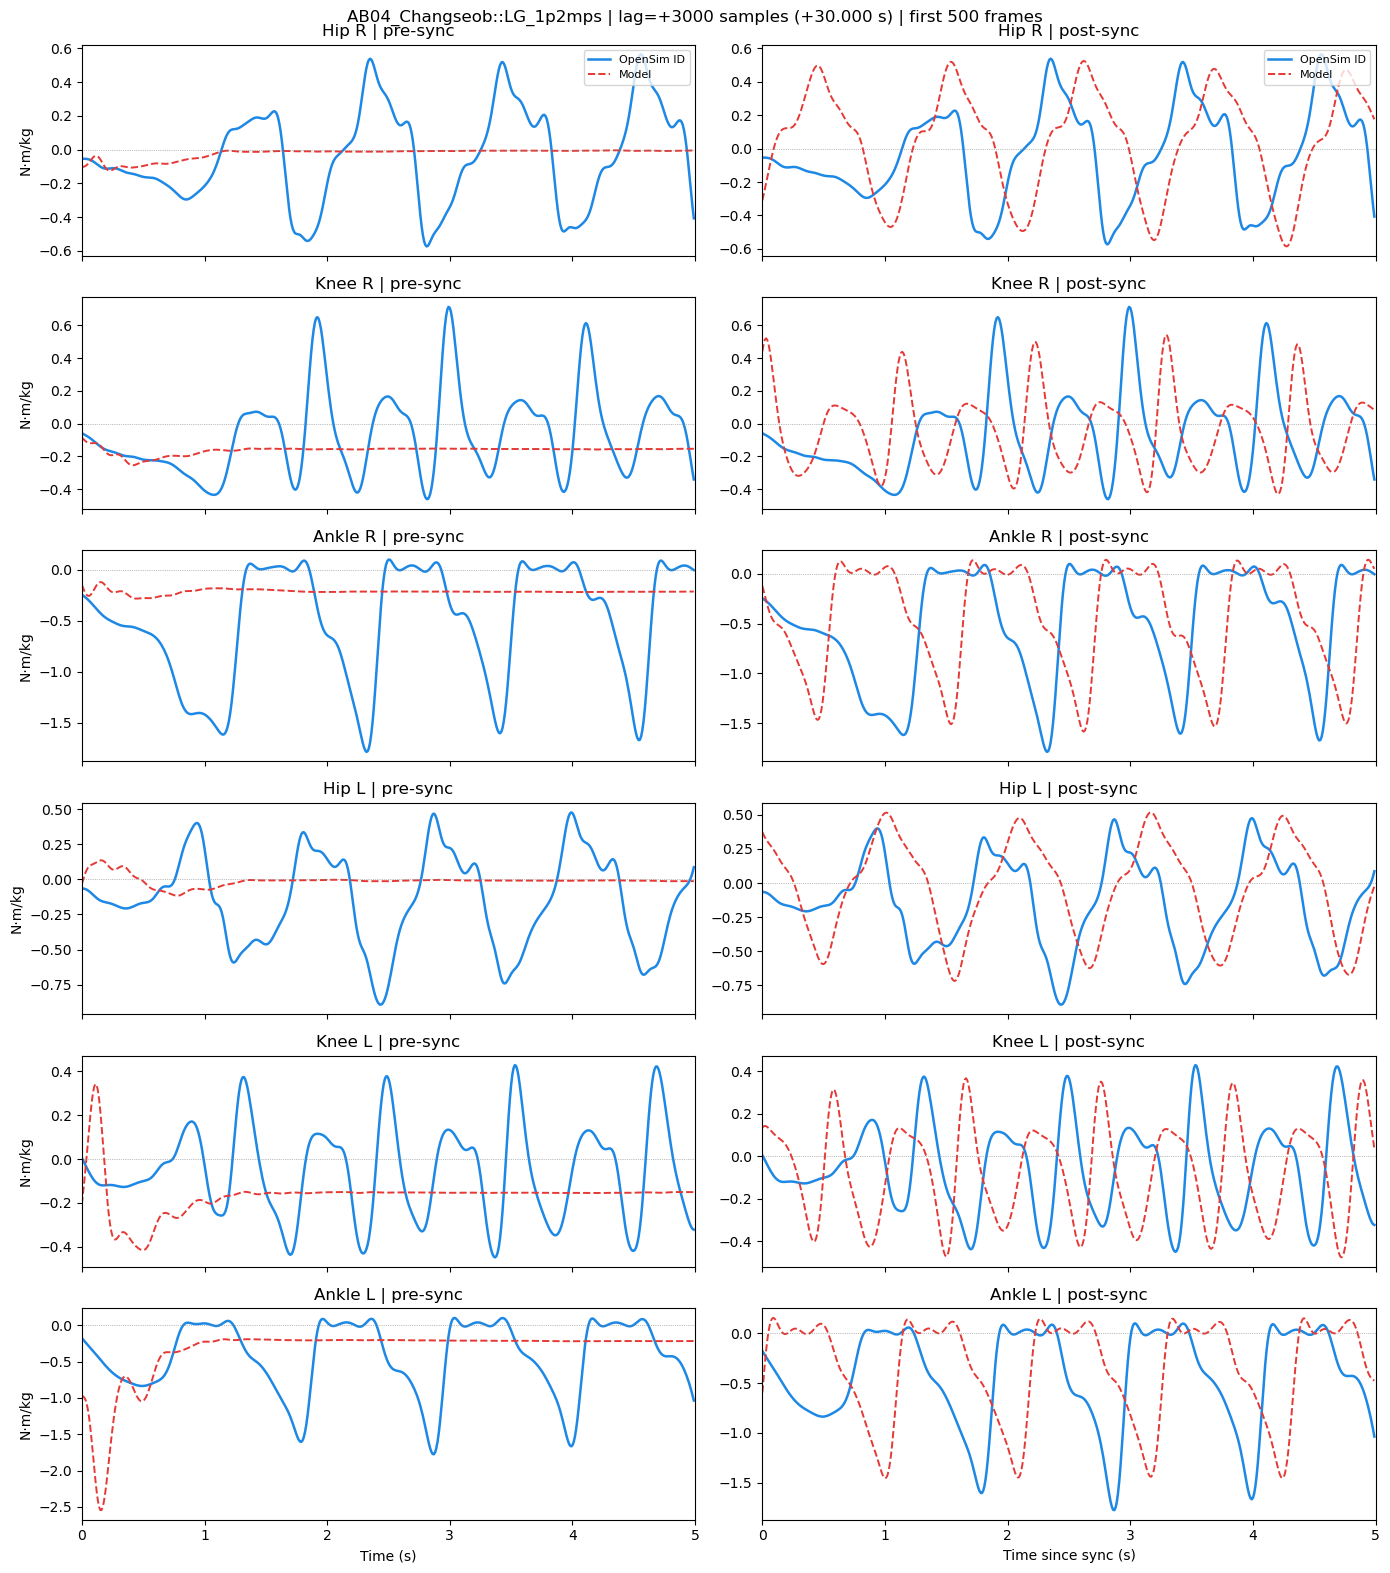

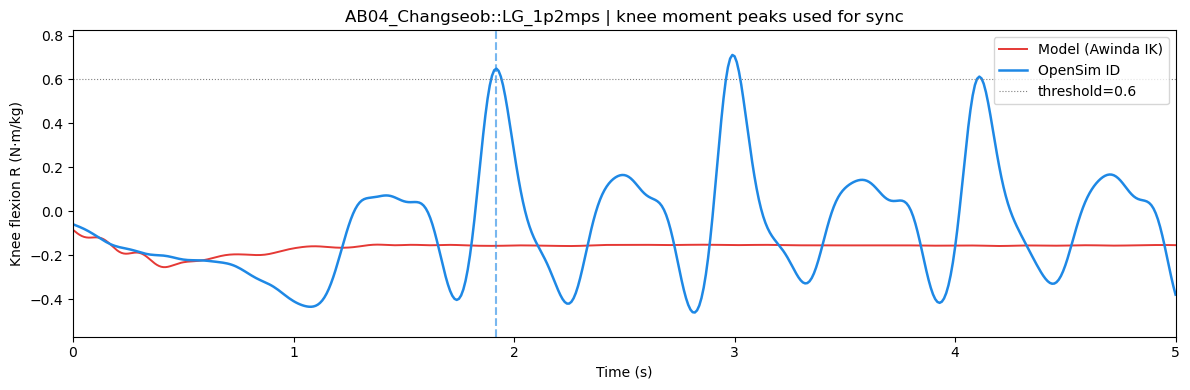

In [11]:
# Pre- vs post-sync waveforms (first 5 s / 500 frames)
fs_hz = SYNC_DEBUG['fs_hz']
preview_n = min(PREVIEW_FRAMES, SYNC_DEBUG['n_sync'])
preview_t = np.arange(preview_n) / fs_hz
names = ['Hip R', 'Knee R', 'Ankle R', 'Hip L', 'Knee L', 'Ankle L']

pred_full = SYNC_DEBUG['pred_full']
id_full = SYNC_DEBUG['id_full']
n_pre_pred = min(PREVIEW_FRAMES, len(pred_full))
n_pre_id = min(PREVIEW_FRAMES, len(id_full))
t_pre_pred = np.arange(n_pre_pred) / fs_hz
t_pre_id = np.arange(n_pre_id) / fs_hz

fig, axs = plt.subplots(6, 2, figsize=(14, 16), sharex='col')
for c, name in enumerate(names):
    ax_pre, ax_post = axs[c]

    ax_pre.plot(t_pre_id, id_full[:n_pre_id, c], label='OpenSim ID', color='#1e88e5', lw=1.8)
    ax_pre.plot(t_pre_pred, pred_full[:n_pre_pred, c], label='Model', color='#e53935', lw=1.4, ls='--')
    ax_pre.set_ylabel('N·m/kg')
    ax_pre.set_title(f'{name} | pre-sync')
    ax_pre.set_xlim(0, PREVIEW_FRAMES / fs_hz)
    ax_pre.axhline(0, color='gray', lw=0.5, ls=':')
    if c == 0:
        ax_pre.legend(loc='upper right', fontsize=8)

    ax_post.plot(preview_t, id_nmpkg_f[:preview_n, c], label='OpenSim ID', color='#1e88e5', lw=1.8)
    ax_post.plot(preview_t, pred_nmpkg_f[:preview_n, c], label='Model', color='#e53935', lw=1.4, ls='--')
    ax_post.set_title(f'{name} | post-sync')
    ax_post.set_xlim(0, PREVIEW_FRAMES / fs_hz)
    ax_post.axhline(0, color='gray', lw=0.5, ls=':')
    if c == 0:
        ax_post.legend(loc='upper right', fontsize=8)

axs[-1, 0].set_xlabel('Time (s)')
axs[-1, 1].set_xlabel('Time since sync (s)')
fig.suptitle(
    f'{TRIAL_KEY} | lag={SYNC_DEBUG["lag"]:+d} samples ({SYNC_DEBUG["lag"] / fs_hz:+.3f} s) | first {PREVIEW_FRAMES} frames',
    fontsize=12,
)
fig.tight_layout()
plt.show()

# Ankle-moment sync markers (full trial)
t_imu = SYNC_DEBUG['t_imu'] - SYNC_DEBUG['t_imu'][0]
t_id_rel = SYNC_DEBUG['t_id'] - SYNC_DEBUG['t_id'][0]
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_imu, SYNC_DEBUG['pred_ankle_full'], label='Model (Awinda IK)', color='#e53935', lw=1.4)
ax.plot(t_id_rel, SYNC_DEBUG['id_ankle_full'], label='OpenSim ID', color='#1e88e5', lw=1.8)
ax.axhline(-ANKLE_MOMENT_NEG_PEAK_THRESHOLD_NMPKG, color='gray', ls=':', lw=0.8, label=f'threshold=-{ANKLE_MOMENT_NEG_PEAK_THRESHOLD_NMPKG}')
ax.axvline(SYNC_DEBUG['pred_peak_idx'] / fs_hz, color='#e53935', ls='--', alpha=0.6)
ax.axvline(SYNC_DEBUG['id_peak_idx'] / fs_hz, color='#1e88e5', ls='--', alpha=0.6)
ax.set_xlim(0, PREVIEW_FRAMES / fs_hz)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Ankle dorsiflexion R (N·m/kg)')
ax.set_title(f'{TRIAL_KEY} | ankle moment negative peaks used for sync')
ax.legend(loc='upper right')
fig.tight_layout()
plt.show()


In [ ]:
d = TRIAL_DATA[TRIAL_KEY]
t = d['t'] - d['t'][0]
names = ['Hip R', 'Knee R', 'Ankle R', 'Hip L', 'Knee L', 'Ankle L']

unit_dd = widgets.Dropdown(options=['N·m/kg', 'N·m'], value='N·m/kg', description='Unit:')
time_slider = widgets.FloatRangeSlider(
    description='Time (s):', min=float(t[0]), max=float(t[-1]),
    value=(float(t[0]), float(t[-1])), step=max((float(t[-1]) - float(t[0])) / 500, 1e-3),
    continuous_update=False, layout=widgets.Layout(width='700px'),
)
out = widgets.Output()


def _draw(unit, t_window):
    scale = 1.0 if unit == 'N·m/kg' else d['mass_kg']
    ylab = unit
    y_pred, y_id = d['pred_nmpkg'] * scale, d['id_nmpkg'] * scale
    t0, t1 = t_window

    fig, axs = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
    for c, ax in enumerate(axs.reshape(-1)):
        m = d['metrics'][c]
        ax.plot(t, y_id[:, c], label='OpenSim ID', color='#1e88e5', lw=1.8)
        ax.plot(t, y_pred[:, c], label='Model', color='#e53935', lw=1.4, ls='--')
        ax.set_title(f"{names[c]} | RMSE={m['rmse_nmpkg']*scale:.3f}, R²={m['r2_nmpkg']:.3f}")
        ax.set_xlim(t0, t1)
        ax.set_ylabel(ylab)
        ax.axhline(0, color='gray', lw=0.6, ls=':')
        if c == 0:
            ax.legend()
    axs[-1, 0].set_xlabel('Time (s)')
    axs[-1, 1].set_xlabel('Time (s)')
    fig.suptitle(
        f"{TRIAL_KEY} | sync: first ankle moment negative peak (≤−{ANKLE_MOMENT_NEG_PEAK_THRESHOLD_NMPKG} N·m/kg, |mag|≥0.8) | lag={d['lag_samples']:+d} samples",
        fontsize=12,
    )
    fig.tight_layout()
    with out:
        out.clear_output(wait=True)
        plt.show()


def _redraw(*_):
    _draw(unit_dd.value, time_slider.value)

unit_dd.observe(_redraw, names='value')
time_slider.observe(_redraw, names='value')
display(widgets.HBox([unit_dd, time_slider]))
display(out)
_redraw()


Output()